 # Vision Agent

In [ ]:
%cd "/content/drive/MyDrive/업무/2026/인사교/헬스케어반(자연어처리)/agent/수업"

/content/drive/MyDrive/업무/2026/인사교/헬스케어반(자연어처리)/agent/수업


In [ ]:
# bitsandbytes : 양자화 라이브러리
# pyngrok : 터널링 도구
!pip install -qU ultralytics openai bitsandbytes streamlit pyngrok

# qwen_vl_utils : Qwen 모델에서 이미지·비디오 전처리 및 입력 변환을 돕는 유틸리티 모듈
# av : Python 바인딩을 제공하는 FFmpeg 래퍼 (비디오/오디오 파일 디코딩 & 인코딩,
#      프레임 단위 접근, 다양한 코덱(H.264, VP9 등) 지원, FFmpeg과 동일한 강력한 포맷 호환성)
!pip install -q qwen_vl_utils av

!pip install -q diffusers

!pip install -qU langchain>=1.0.0 langchain-community langchain-experimental langchain-text-splitters langchain_tavily
!pip install -qU langchain-openai langchain-google-genai

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.4 MB/s eta 0:00:00


In [ ]:
import os

In [ ]:
# OpenAI Key 환경변수 설정
with open("./key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [ ]:
# Google Key 환경변수 설정
with open("./key/.google_api_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['GOOGLE_API_KEY'] = api_key

In [ ]:
import matplotlib.pyplot as plt
import cv2, base64, time, os, torch, io, json, re
from PIL import Image
import numpy as np
from tqdm import tqdm
import base64

from ultralytics import YOLO
from openai import OpenAI
import google.generativeai as genai

# AI 모델을 웹 데모로 손쉽게 만드는 라이브러리
import gradio as gr
from pyngrok import ngrok
from pathlib import Path

from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
# 양자화
from transformers import BitsAndBytesConfig

# 모델에 대한 비디오 데이터 준비
from qwen_vl_utils import process_vision_info
from diffusers import StableDiffusionPipeline
from diffusers import StableDiffusion3Pipeline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
 # 라이브러리 import
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
# 노드 : 그래프에서의 작업 단위, 실제 작업을 수행하는 함수
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown

In [ ]:
from langchain.tools import tool # 에이전트가 스스로 선택하는 도구
# 모델 연동
import openai
from langchain.chat_models import init_chat_model
from langchain_openai.embeddings import OpenAIEmbeddings

# 프롬프트
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 메모리 기능
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.messages import HumanMessage, AIMessage

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# 간단한 Vision Agent 구현(단순 반사 에이전트)

- 상태정의

In [ ]:
class VisionState(TypedDict) :
  model_path : Annotated[str , "model version"]
  image_path : Annotated[str , "Image path"]
  detections : Annotated[List[Dict[str,str]], "Detection results"]
  target : Annotated[str, "target class name"]
  threshold : Annotated[float, "confidence threshold"]
  target_detected : Annotated[str, 'target detect result, yes or no']
  origin_image : Annotated[str, 'origin image']

- 인식노드 정의

In [ ]:
def VisionPerception(s: VisionState) -> VisionState:
  # 모델생성
  model = YOLO(s['model_path'])
  # 모델추론
  results = model(s['image_path'])
  # 인식모델의 추론정보 추출하기
  detections = [] # 추론결과를 담을 리스트
  for box in results[0].boxes :
    # 검출된 객체의 첫번째 인덱스 값을 반환(가장 신뢰도가 높은 값)
    cls_id = int(box.cls[0].item())
    # 검출객체의 인덱스를 라벨로 변환
    label = model.names[cls_id]
    # 객체에 대한 확신도 추출
    conf = float(box.conf[0].item())
    # 객체의 위치정보 추출
    x1,y1,x2,y2 = box.xyxy[0]
    # 추출된 결과값을 리스트에 저장
    detections.append({'label':label, "confidence": f"{conf:.2f}",
                       'x1' : str(int(x1)), 'y1' : str(int(y1)),
                       'x2' : str(int(x2)), 'y2' : str(int(y2))})
  # 오리진 이미지 추출
  img = results[0].orig_img.copy()
  # numpy 배열을 base64로 직렬화
  _, buffer = cv2.imencode(".png", img)
  base64_encoded = base64.b64encode(buffer)
  base64_string = base64_encoded.decode('utf-8')

  return VisionState(detections = detections, origin_image=base64_string)

- 의사결정 노드 정의

In [ ]:
def DecisionMake(s:VisionState) -> VisionState :
  for d in s['detections'] : # 상태에서 인식된 객체검출 결과를 반복처리
    # 지정된 클래스 이름과 같고 확신도 임계치를 넘는 경우
    if d['label'] == s['target'] and float(d['confidence']) >= s['threshold'] :
      print(f"======[target detected] 지정된 {s['target']}이 검출되었습니다.")
      return VisionState(target_detected = 'yes')
  return VisionState(target_detected = 'no')

- 행동 노드 정의

In [ ]:
def AgentAction(s:VisionState) -> VisionState :
  # 메세지 발송
  if s['target_detected'] == 'yes' :
    print("알림 발생, 지정된 메세지가 발송됩니다.")
  # 검출된 객체 이미지 출력
  ## base64 to imge
  img_bytes = base64.b64decode(s['origin_image'])
  nparr = np.frombuffer(img_bytes, np.uint8)
  img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

  ## 색공간 변환 BGR -> RGB
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  # 사각형 그리기
  for d in s['detections'] :
    if d['label'] == s['target'] and float(d['confidence']) >= s['threshold'] :
      cv2.rectangle(img_rgb, # 그림을 그릴 이미지
                    (int(d['x1']), int(d['y1'])), # 시작 좌표
                    (int(d['x2']), int(d['y2'])), # 끝 좌표
                    (0,255,0), # 선 색상
                    2) # 선 두께
  plt.imshow(img_rgb)
  plt.axis('off')
  plt.show()

  return VisionState() # 추후에 탐지결과 이미지를 state에 업데이트하는 것도 고려

- 그래프 구축

In [ ]:
# 그래프 베이스 생성
workflow = StateGraph(VisionState)

# 노드 정의
workflow.add_node("VisionPerception", VisionPerception)
workflow.add_node("DecisionMake", DecisionMake)
workflow.add_node("AgentAction", AgentAction)

# 엣지 정의
workflow.add_edge(START,"VisionPerception")
workflow.add_edge("VisionPerception","DecisionMake")
workflow.add_edge("DecisionMake","AgentAction")
workflow.add_edge("AgentAction",END)

# 컴파일
app = workflow.compile()


image 1/1 /content/drive/MyDrive/업무/2026/인사교/헬스케어반(자연어처리)/agent/수업/data/bus.png: 384x640 10 persons, 1 car, 1 bus, 2 backpacks, 92.0ms
Speed: 1.4ms preprocess, 92.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
...
======[target detected] 지정된 person이 검출되었습니다.
알림 발생, 지정된 메세지가 발송됩니다.


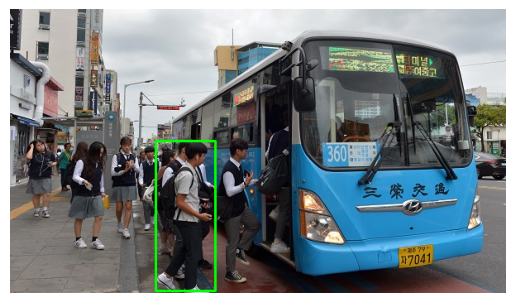

In [ ]:
# 그래프 실행
input = VisionState(
    model_path = "./model/yolo12n.pt",
    image_path = "./data/bus.png",
    target = "person",
    threshold = 0.8
)
rs = app.invoke(input = input)

In [ ]:
rs

{'model_path': './model/yolo12n.pt',
 'image_path': './data/bus.png',
 'detections': [{'label': 'bus',
   'confidence': '0.94',
   'x1': '193',
   'y1': '26',
   'x2': '574',
   'y2': '322'},
  {'label': 'person',
   'confidence': '0.84',
   'x1': '176',
   'y1': '159',
   'x2': '248',
   'y2': '340'},
  {'label': 'person',
   'confidence': '0.76',
   'x1': '121',
   'y1': '153',
   'x2': '155',
   'y2': '278'},
  {'label': 'person',
   'confidence': '0.75',
   'x1': '71',
   'y1': '159',
   'x2': '117',
   'y2': '291'},
  {'label': 'person',
   'confidence': '0.75',
   'x1': '16',
   'y1': '156',
   'x2': '57',
   'y2': '252'},
  {'label': 'car',
   'confidence': '0.72',
   'x1': '562',
   'y1': '171',
   'x2': '600',
   'y2': '206'},
  {'label': 'person',
   'confidence': '0.71',
   'x1': '248',
   'y1': '155',
   'x2': '294',
   'y2': '331'},
  {'label': 'person',
   'confidence': '0.54',
   'x1': '151',
   'y1': '164',
   'x2': '182',
   'y2': '270'},
  {'label': 'person',
   'conf

# 시각-언어-행동 통합 Agent 구현(모델 기반 반사 에이전트)

- 상태정의

In [ ]:
class VisionAgentState(TypedDict) :
  image_path : Annotated[str, "input image path"]
  origin_image : Annotated[str, "origin image data"]
  model_path : Annotated[str , "model version"]
  detections : Annotated[List[Dict[str,str]], "Detection results"]
  caption_text : Annotated[str, 'caption result']

- 이미지 입력 노드

In [ ]:
def InputImage(s:VisionAgentState) -> VisionAgentState :
  # 이미지 오픈
  img = cv2.imread(s['image_path'])

  if img is None :
    return VisionAgentState(origin_image="None") # 이미지가 오픈되지 않는 경우 처리
  else :
    # base64로 직렬화
    _, buffer = cv2.imencode(".jpg", img)
    base64_encoded = base64.b64encode(buffer)
    base64_string = base64_encoded.decode('utf-8')

    return VisionAgentState(origin_image=base64_string)

- 이미지 분석 노드

In [ ]:
def VisionAnalysis(s:VisionAgentState) -> VisionAgentState :
  # 모델 생성
  model = YOLO(s['model_path'])
  # 모델 추론
  ## base64 to imge
  img_bytes = base64.b64decode(s['origin_image'])
  nparr = np.frombuffer(img_bytes, np.uint8)
  img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
  results = model(img)
  # 예측정보 추출(정리)
  detections = [] # 추론결과를 담을 리스트
  for box in results[0].boxes :
    # 검출된 객체의 첫번째 인덱스 값을 반환(가장 신뢰도가 높은 값)
    cls_id = int(box.cls[0].item())
    # 검출객체의 인덱스를 라벨로 변환
    label = model.names[cls_id]
    # 객체에 대한 확신도 추출
    conf = float(box.conf[0].item())
    # 객체의 위치정보 추출
    x1,y1,x2,y2 = box.xyxy[0]
    # 추출된 결과값을 리스트에 저장
    detections.append({'label':label, "confidence": f"{conf:.2f}",
                       'x1' : str(int(x1)), 'y1' : str(int(y1)),
                       'x2' : str(int(x2)), 'y2' : str(int(y2))})
  return VisionAgentState(detections=detections)

- 이미지 설명 노드

In [ ]:
def CaptionExtract(s:VisionAgentState) -> VisionAgentState :
  prompt = f'''
    당신은 위험 상황을 감지하는 vision AI 입니다.
    아래 객체 탐지결과(detected_results)를 참고하여
    이미지의 상황을 설명하는 caption text를 구성하세요.
    caption text는 5줄 이내로 작성하세요.

    detected_results : {s['detections']}
  '''
  # OpenAI모델 생성 및 멀티모달 추론 호출
  client = OpenAI()
  response = client.responses.create(
      model="gpt-4o", # 모델이름
      input=[
          {
              'role' : 'user',
              "content" : [
                  {"type":"input_text", "text" : prompt},
                  {"type":"input_image", "image_url" : f"data:image/jpg;base64,{s['origin_image']}"}
              ]
          }
      ]
  )
  return VisionAgentState(caption_text=response.output_text)

- 행동 노드

In [ ]:
import requests

In [ ]:
# tool 정의
@tool
def send_message(msg : str) :
  '''
      이미지 caption 결과 위험한 상황이면 메세지 송신
      안전한 상황인 경우 메세지 송신하지 않음
  '''
  WEBHOOK_URL = "https://discord.com/api/webhooks/1523876039858720790/exmLym_nXrvfMcSDFD0AYA4dpn-DeWE6PtB3RSx7YWAs2BcF_w90rMDQhYiEfhHylQkL"

  response = requests.post(
      WEBHOOK_URL,
      json={
          "content": msg
      }
  )

In [ ]:
def ActionExecute(s:VisionAgentState) -> VisionAgentState:
  # 모델생성
  llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=500, temperature=0)
  # 도구연결
  llm_with_tools = llm.bind_tools([send_message])
  # 프롬프트 템플릿 구성
  template = ChatPromptTemplate.from_messages([
      ('system','''
        너는 위험상황에 따라 action을 취하는 Vision AI야
        아래 caption text와 detections를 보고 아래 조건에 맞춰서 행동한다

        - 조건
          1. 긴급한 위험상황에 대해서 tool을 이용해 메세지를 송신한다.
          2. 주의 또는 안전한 상황의 경우 tool을 사용하지 않고 현재 상황을 설명하는 리포트를 구성해서 보여준다

        caption text : {caption_text}

        detections : {detections}
      ''')
  ])
  # 체인구성하기
  action_chain = template | llm_with_tools
  # 체인호출
  rs = action_chain.invoke({
      'caption_text' : s['caption_text'],
      'detections' : s['detections']
  })
  # tool 호출하기
  tool_map = {
      "send_message" : send_message
  }
  for tool_call in rs.tool_calls :
    tool = tool_map[tool_call['name']]
    tool.invoke(tool_call['args'])

  # 문자열메세지 파싱
  parser = StrOutputParser()
  output = parser.invoke(rs)
  print(output)

  return VisionAgentState()

- 그래프 구성

In [ ]:
# 그래프 베이스 생성
workflow = StateGraph(VisionAgentState)
# 노드 추가
workflow.add_node("InputImage",InputImage)
workflow.add_node("VisionAnalysis",VisionAnalysis)
workflow.add_node("CaptionExtract",CaptionExtract)
workflow.add_node("ActionExecute",ActionExecute)
# 엣지 추가
workflow.add_edge(START, "InputImage")
workflow.add_edge("InputImage", "VisionAnalysis")
workflow.add_edge("VisionAnalysis", "CaptionExtract")
workflow.add_edge("CaptionExtract", "ActionExecute")
workflow.add_edge("ActionExecute",END)
# 컴파일
app = workflow.compile()

In [ ]:
# 실행
input = VisionAgentState(
    model_path = "./model/yolo12n.pt",
    image_path = "./data/bus.png"
)
rs = app.invoke(input=input)


0: 384x640 10 persons, 1 car, 1 bus, 1 backpack, 251.3ms
Speed: 3.0ms preprocess, 251.3ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)



In [1]:
rs

NameError: name 'rs' is not defined